<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/Liner_Regression_Sales_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Common Business Question**

**- How can we forcast sales on historical sales data & marketing expenditure.**

**- In lenar Regression we can find the output from the input.**

**- We training a model from avilable past data & we predict the possiblity or number as a output iu term of forcasting.**

**Liner Regression analysis is a statistical method used to estimate the relationships among veriables.**

**It helps to understanding how the Dependent varibale can changes when independent varible is varies.**

# **Problem Statement :**

**-Consider an online retailer of mobile & tablet**

**-Crusial to stay ahead of market trend and consumer perferances of maximize sales**

**-Need to effectively manage inventory and marketing efforts to attract and retain customers**

# **Objective**

**-Maximize a sales (Accurately forcast the sales trends to help to make informed decisions)**

**-Identify the key levers that can influence sales**

[ Forcasting a sales, one needs to collect historical sales data, identify patterns, trends and validate the model]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:.2f}'.format

from IPython.display import display

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/Sales.csv')
  print("Data Loaded successfully 🚀")

except Exception as a :
  print("fileNotFound!")
  print(a)

Data Loaded successfully 🚀


In [3]:
df = data.copy()

## **Data Overview**

In [4]:
df.shape

(3000, 10)

In [5]:
display(df.head())
print()
display(df.tail())

,Advertising Expenditure,Campaign Engagement Score,Discount Percentage,Average Customer Rating,Product Price,Return Rate,Length of Product Description,Region,Popularity,Sales
0,644.05,54.57,25.27,4.60,1599.58,2.13,231.19,East,High,26246.91
1,521.48,46.88,35.08,4.36,1586.46,1.55,262.69,West,Very High,21432.17
2,540.08,42.29,12.62,4.57,1301.64,2.27,324.35,South,Very High,22551.92
3,627.94,61.83,31.59,4.23,1601.04,1.04,447.71,South,Very High,27792.29
4,471.15,31.06,9.20,4.82,1496.73,3.28,310.06,East,Moderate,17354.77


,Advertising Expenditure,Campaign Engagement Score,Discount Percentage,Average Customer Rating,Product Price,Return Rate,Length of Product Description,Region,Popularity,Sales
2995,557.10,39.73,25.51,4.71,1491.42,1.31,143.79,North,Moderate,21332.41
2996,667.12,54.75,30.63,4.37,1259.08,0.43,378.53,West,High,26780.92
2997,653.70,43.98,28.18,4.24,1689.20,0.96,251.93,South,Moderate,21217.39
2998,539.52,30.62,26.91,4.42,1103.44,2.27,320.80,West,High,22094.56
2999,644.65,63.92,31.83,4.43,1714.54,0.75,281.43,South,Very High,21770.07


### **Checking the attributes types**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Advertising Expenditure        3000 non-null   float64
 1   Campaign Engagement Score      3000 non-null   float64
 2   Discount Percentage            3000 non-null   float64
 3   Average Customer Rating        3000 non-null   float64
 4   Product Price                  3000 non-null   float64
 5   Return Rate                    3000 non-null   float64
 6   Length of Product Description  3000 non-null   float64
 7   Region                         3000 non-null   object 
 8   Popularity                     3000 non-null   object 
 9   Sales                          3000 non-null   float64
dtypes: float64(8), object(2)
memory usage: 234.5+ KB


**Observation's :**

- In table there are 10 columns.
- there are 2 categorical variable & 8 numerical variable.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Advertising Expenditure,3000.00,607.73,82.03,97.25,561.98,616.12,666.33,801.50
Campaign Engagement Score,3000.00,49.46,13.17,0.00,40.70,49.48,58.15,98.75
Discount Percentage,3000.00,29.00,4.70,0.00,26.22,29.55,32.26,40.54
Average Customer Rating,3000.00,4.41,0.23,3.65,4.25,4.43,4.58,4.87
Product Price,3000.00,1434.72,222.83,9.78,1306.16,1461.30,1587.67,2000.56
Return Rate,3000.00,1.67,0.90,0.03,0.95,1.54,2.29,4.53
Length of Product Description,3000.00,248.70,60.80,42.00,207.08,249.35,288.88,496.00
Sales,3000.00,23858.64,3611.75,3257.60,21632.97,24087.13,26421.77,34421.43


## **Observation's :**

- On an average retailer has sold mobile & tablets wort ~$23.8K.
- On an average ~600 dollers have been sold on advertising. Minimum advertise expenditure is 97.25 & maximum Adv.expenditure 801 dollars.
- On an average retailer give discount on mobile & tables around 29%.
Maximum discount is around 40.54%. Also some products they have sold on Zero discount.
- Avg. Return rate is 4.41% & Std. is around 0.90 means, variate is 0.20 which is moderate variation. Maximum return rate is 4.53 out of 3000 sold product 1305 products were returned.
- Average cuatomer rating ~ 4.41.


In [8]:
df.isnull().sum()

,0
Advertising Expenditure,0
Campaign Engagement Score,0
Discount Percentage,0
Average Customer Rating,0
Product Price,0
Return Rate,0
Length of Product Description,0
Region,0
Popularity,0
Sales,0


## **Observation :**

- There is no missing values in the data.

In [9]:
df.duplicated().sum()

np.int64(0)

## **Observation's :**

- There is no duplicate values in the data

# **Exploratory Analysis**


##**Univariate Analysis**

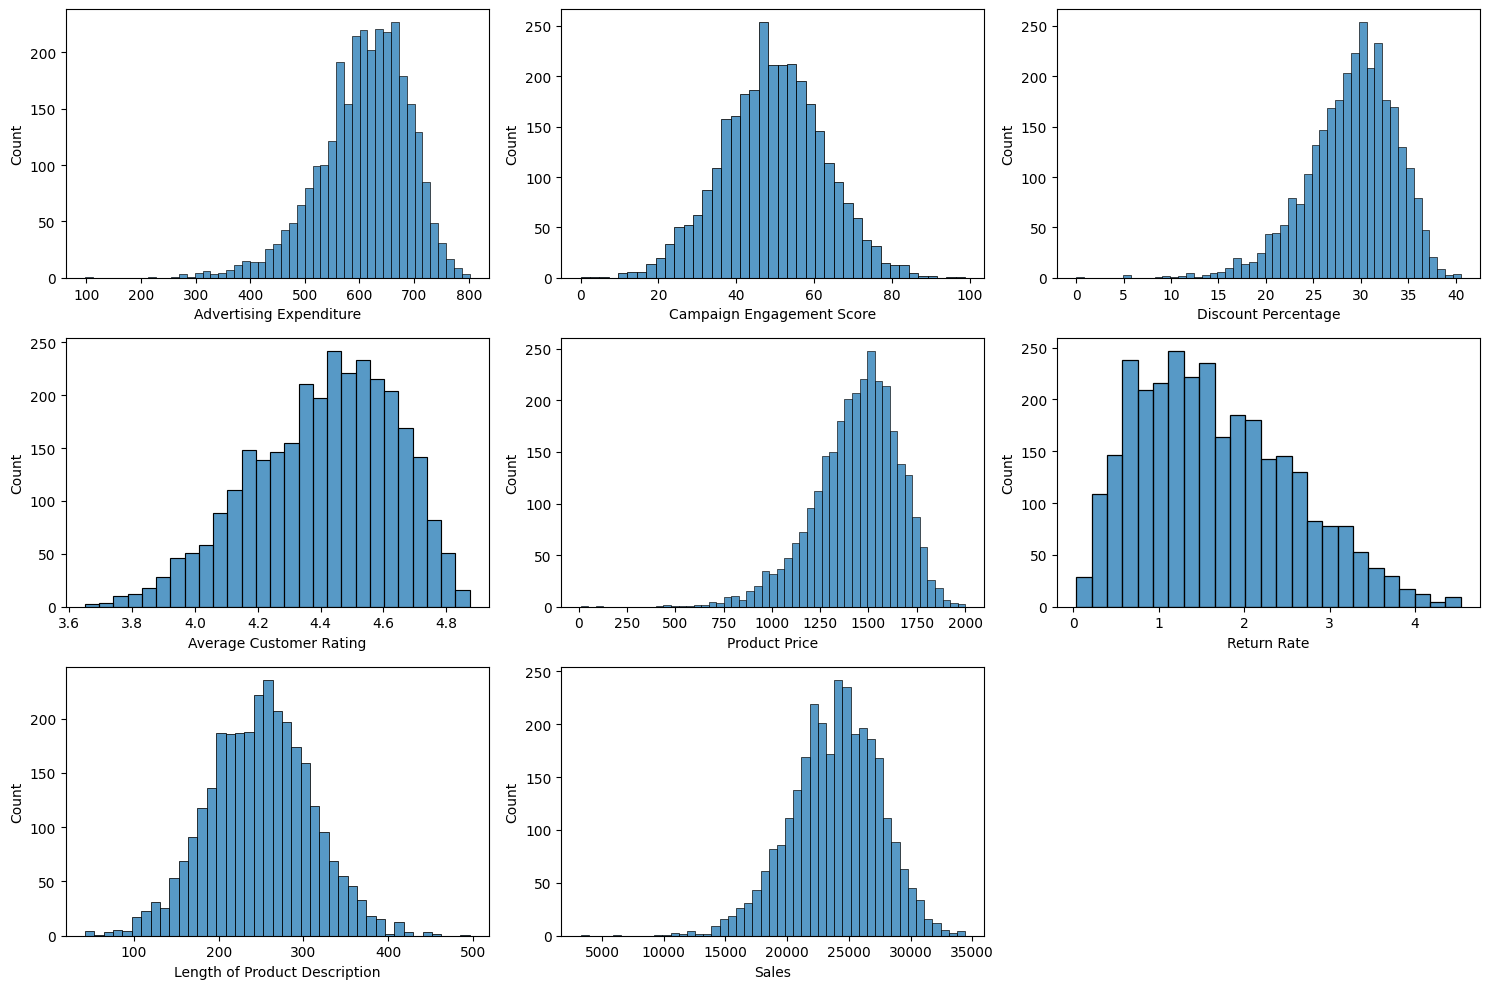

In [20]:
plt.figure(figsize = (15, 10))

# selecting numerical variables
features = df.select_dtypes(include = ['number']).columns.tolist()

for i, feature in enumerate(features) :
  plt.subplot(3, 3, i+1)
  sns.histplot(data=df, x = feature)

plt.tight_layout()
plt.show()

## **Observation :**

- Advertising Expenditure, Discount percentage, Average customer rating, product price, sales are left-Skewed distribution.

- Return rate is right-skewed distribution.

- Campaign Engagement score & length of product description are approx normly distributed.

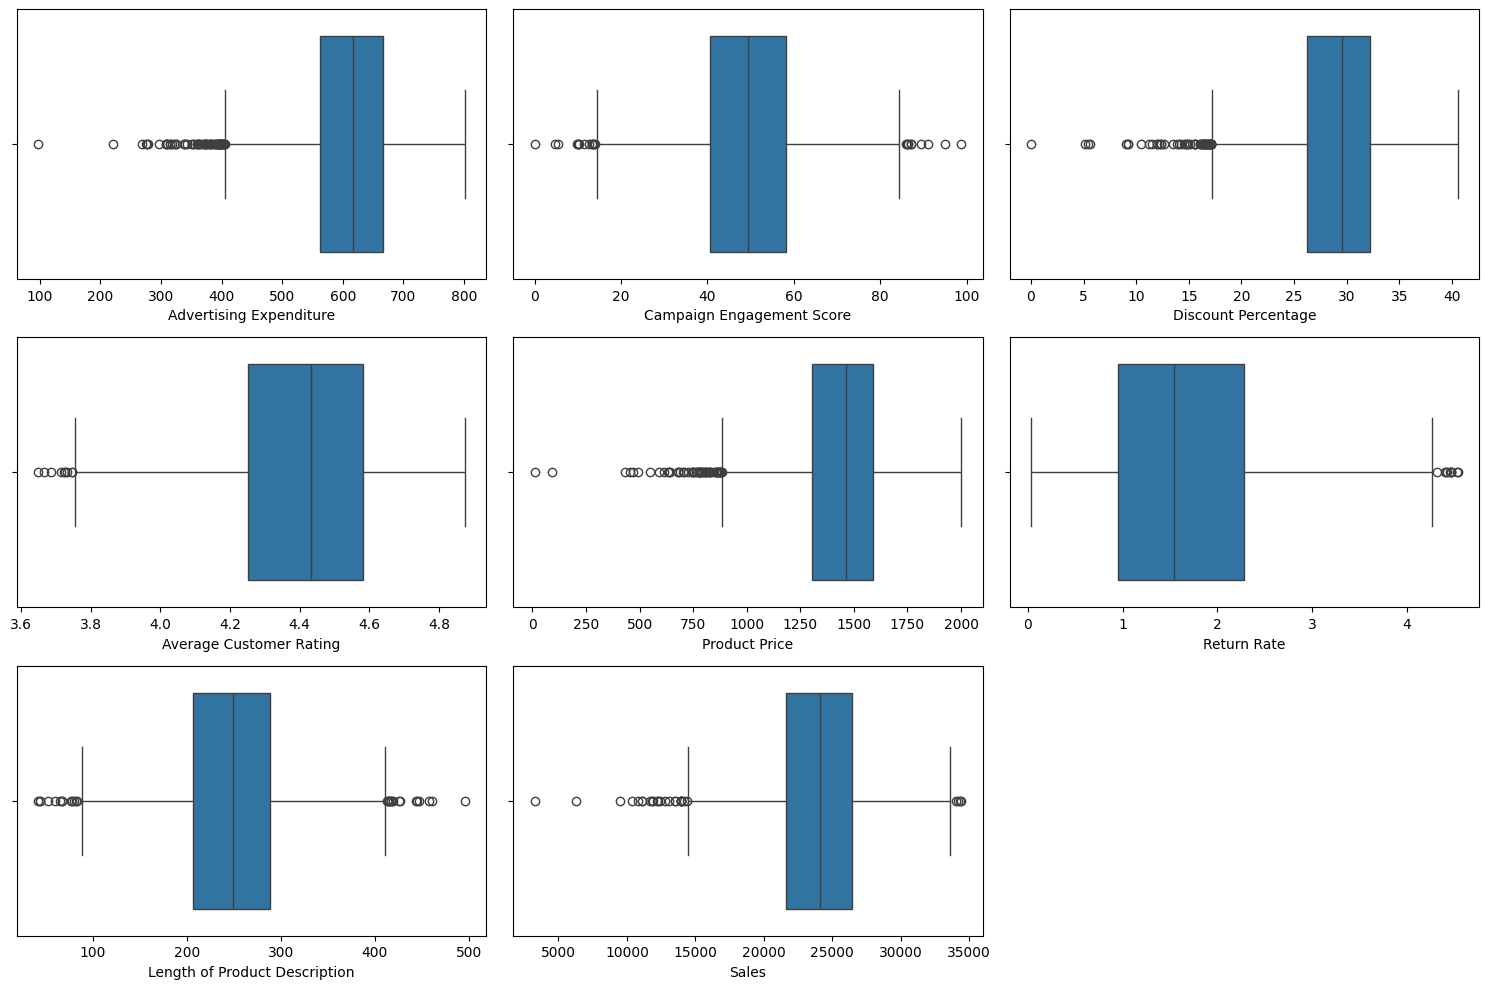

In [21]:
plt.figure(figsize = (15, 10))

features_1 = df.select_dtypes(include = ['number']).columns.tolist()

for i, feature in enumerate( features_1) :
  plt.subplot(3, 3, i+1)
  sns.boxplot(data=df, x = feature)

plt.tight_layout()
plt.show()

## **Observation's :**

- all the variables has outliers.
- Here as we above mentioned in histplot skeweness are same in boxplot.
- Outliers are cause to missinfo or missguiding/ influences about the data, decisions, also model performances.

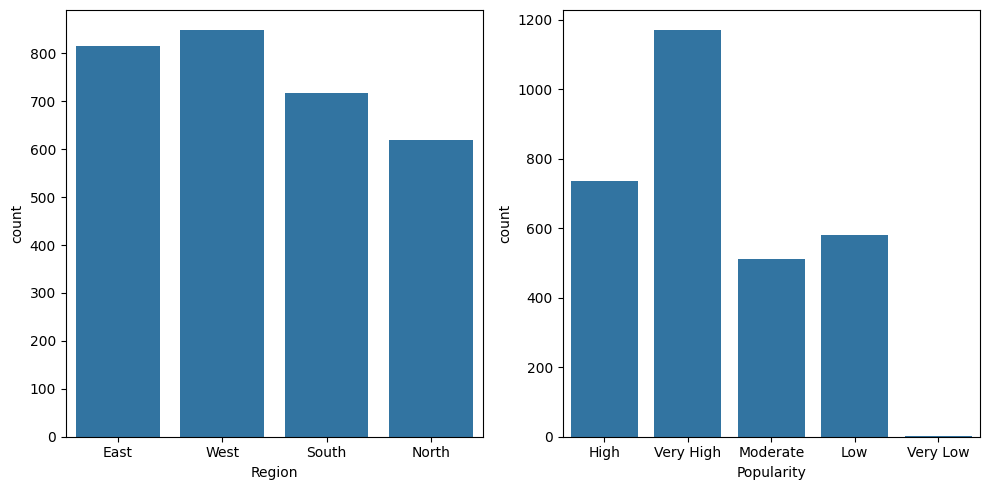

In [22]:
plt.figure(figsize = (10, 5))

features_2 = df.select_dtypes(exclude = ['number']).columns.tolist()

for j, features in enumerate(features_2):
  plt.subplot(1, 2, j+1)
  sns.countplot(data=df, x = features )

plt.tight_layout()
plt.show()

## **Observation's :**

- The North region has fewer data points than the others.

- Most of the mobiles & Popularity sold are very popular, & negligible amount of them are very unpopular.

# **Bivariate Analysis**

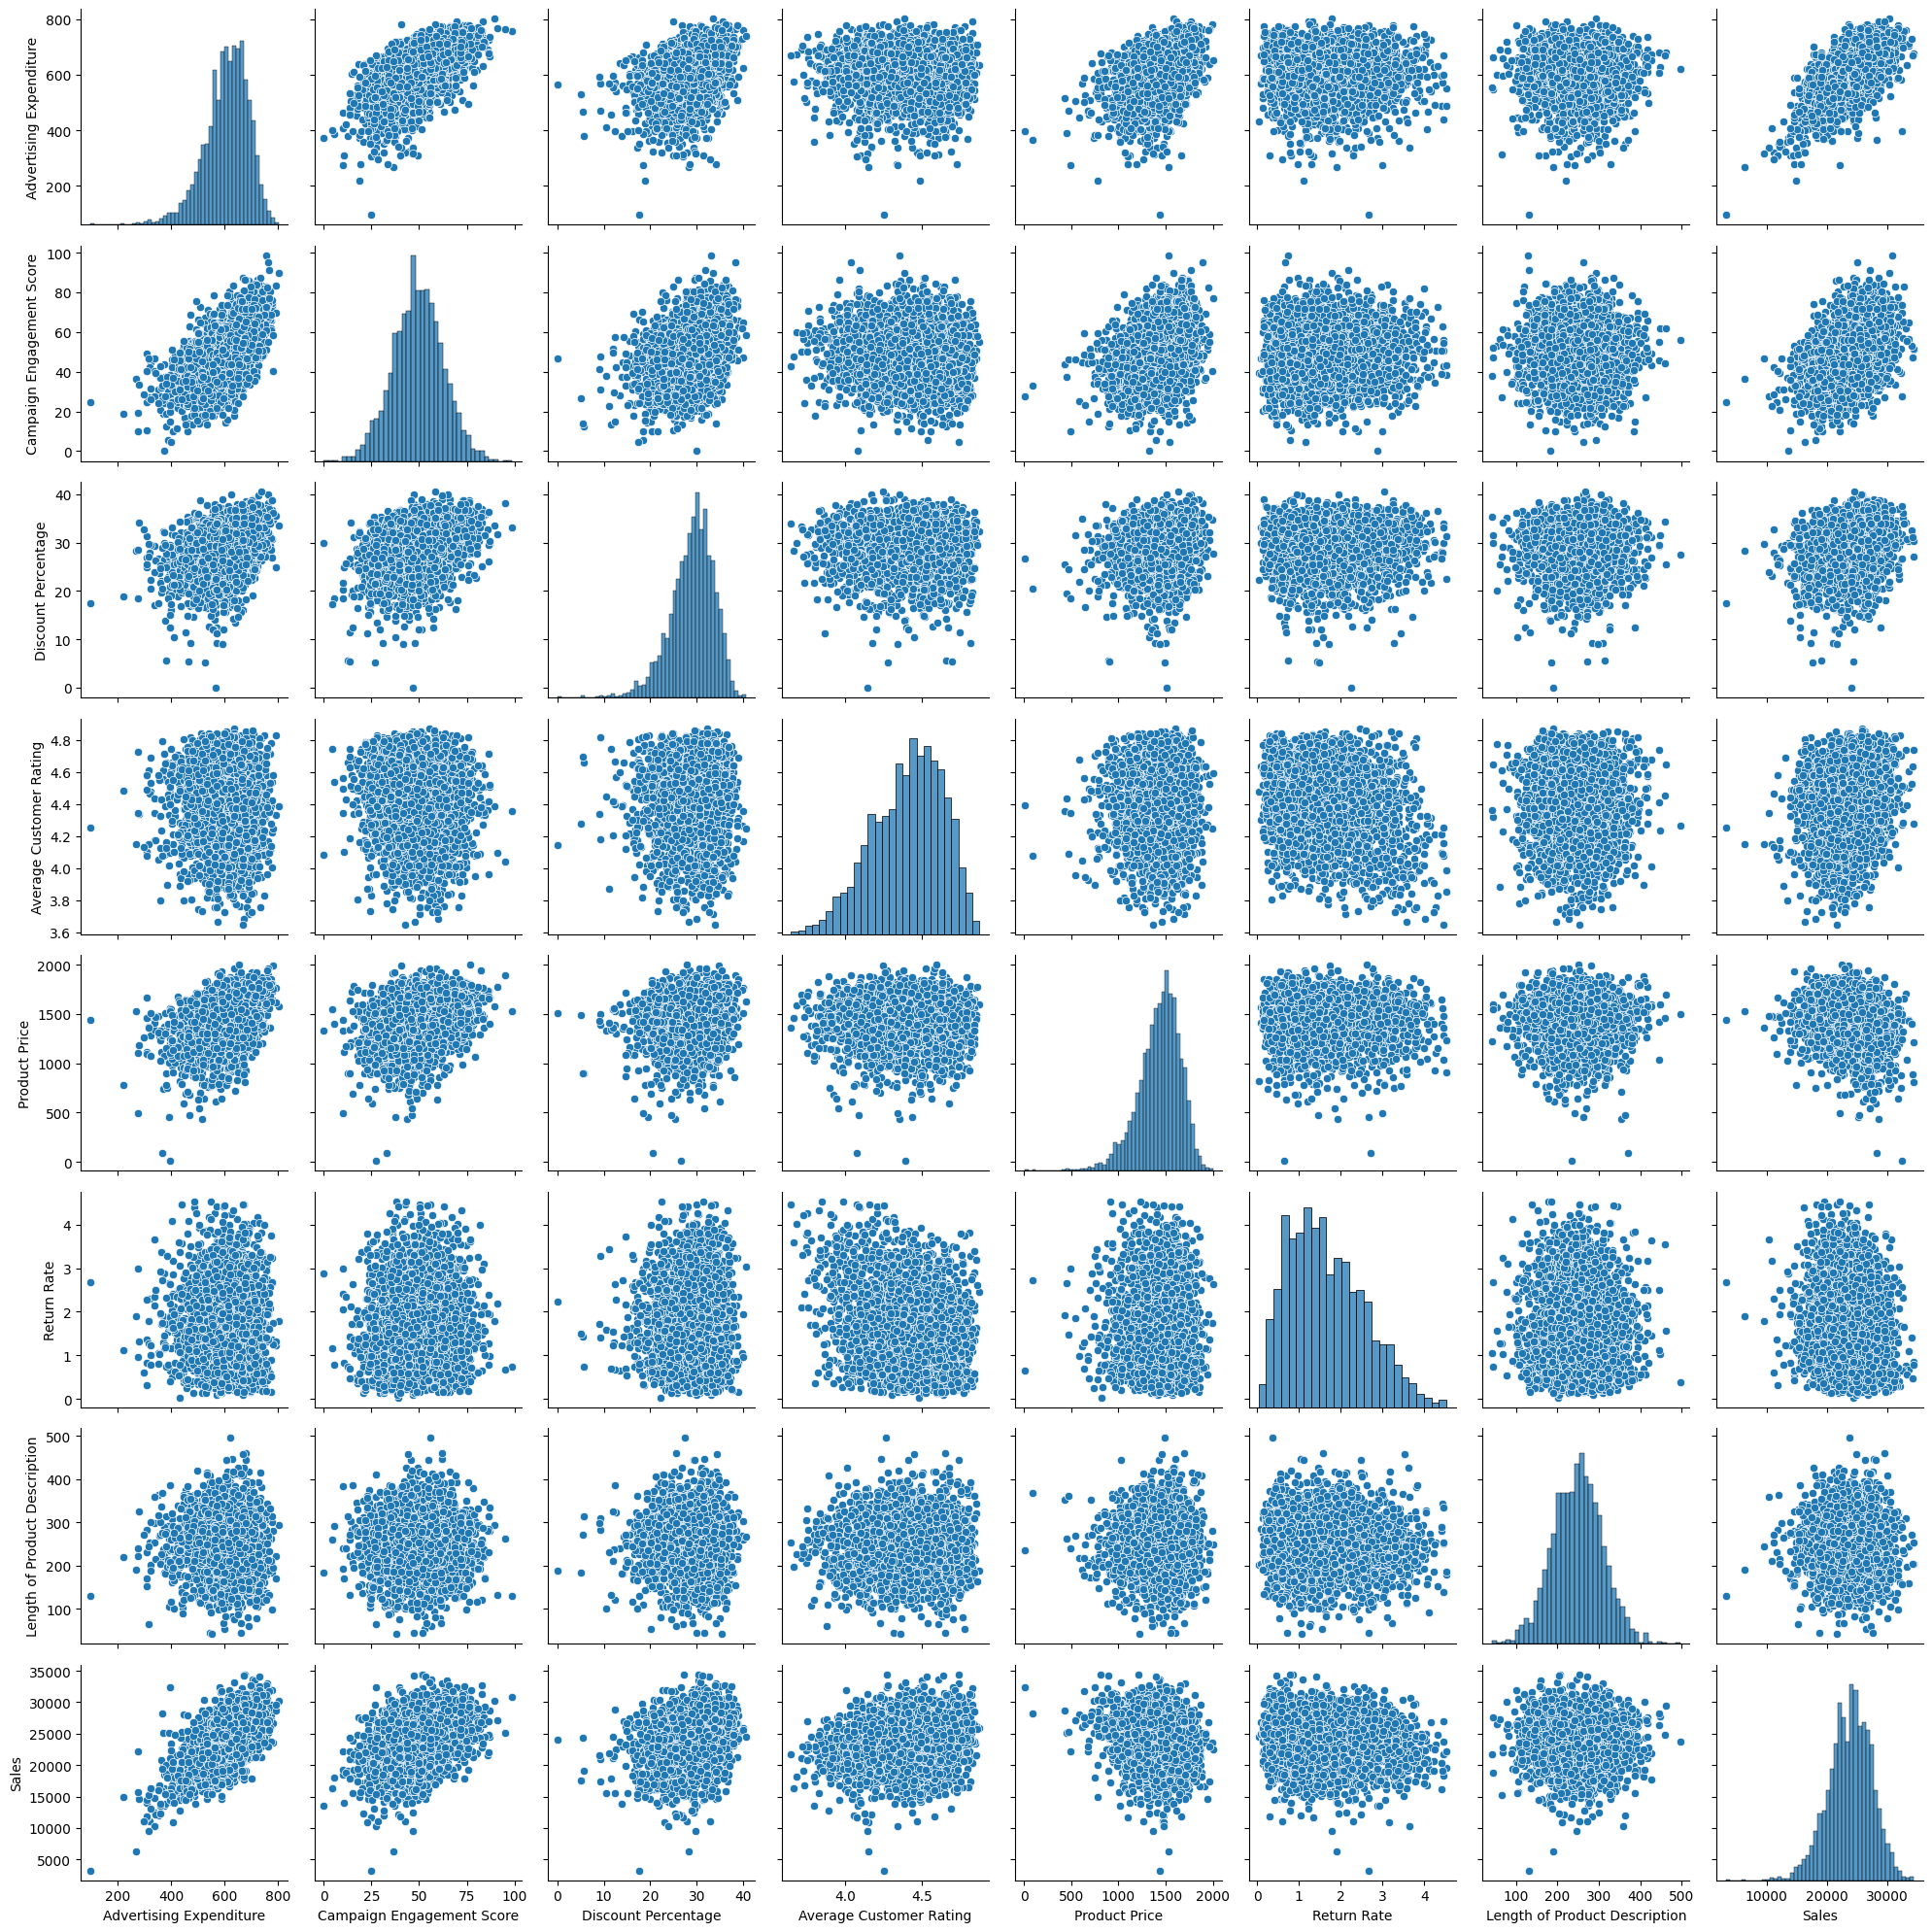

In [17]:
sns.pairplot(df)
plt.tight_layout()
plt.show()

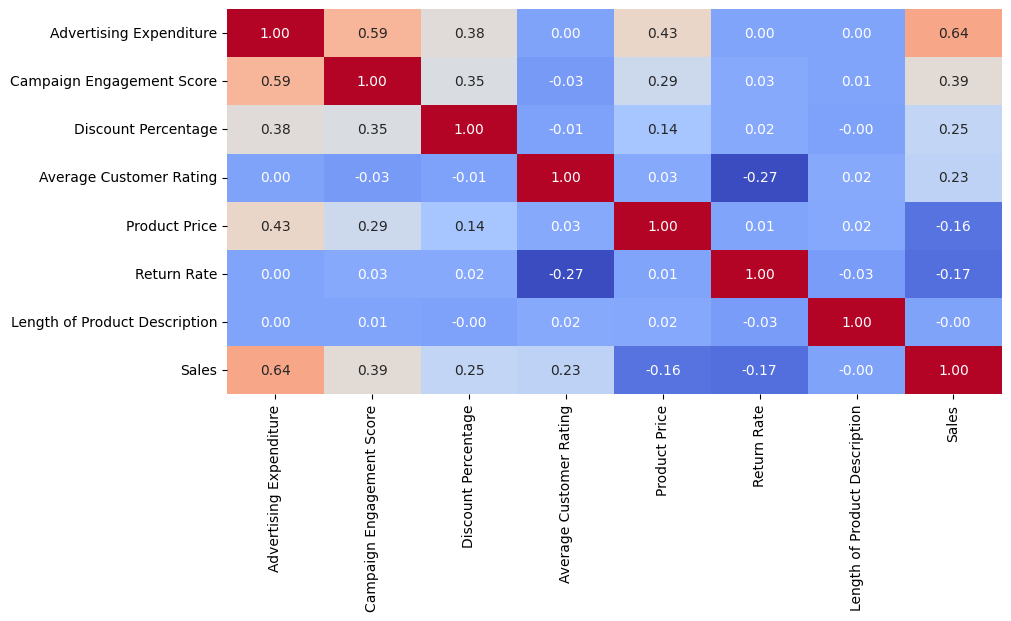

In [14]:
 # Checking the correlationship between the variables
plt.figure(figsize = (10,5))
sns.heatmap(df.corr( numeric_only = True), annot = True, cbar = False, fmt = '0.2f', cmap = 'coolwarm');

## **Observation's :**

- As we can see, Sales & Advertising Expenditure having postive correlation with each other. if the more Advertising expenditure sales tends to more. some outliers is there but still having positive relation.

- Campaign Engagement Score & sales is also a postive correaltion with each other. except some outliers, More customer engagement tends to sales increase.

- Discount Percentage & sales having postive correlation with each other, except some outliers more discount offering tends to more sales.

- Average customer rating is not that much influencing on sales, rating data is widly spreded.

- Product price & sales is negative correlation with each other, if the price increases sale will get Affected. sales goes down. Not that much strong negative corr. but some influencing to sales.

- Return rate is also not that much affected on sales.

- Lenght of product description is not correlation with sales.


Here we are finding the correlation between the target varibale(dependent veriable ) with independet veriables.

### **- Positive Correlation :** Both the variables are going on same direction then we call positive Correaltion

### **- Negative Correlation :** Both the variables are going on opposite directions then we call Negative Correlation

- Correlation is a statistical measure that descirbes the strength and direction of a relationship between two variables.

- Correlation we can find also from visually identify relationship  between the pair of variables from two aspects = direction and strength.

- But we need quntitative measure of the relationship.

- sns.sactterplot(data=df, x = 'dependent column', y = 'Independent columns')

- there are 3 correlations, 'Postive Corr.', 'Negative Corr.', 'No Correlation'

- Correlation typically ranges between the -1 and 1. ( either they are postive or negative )





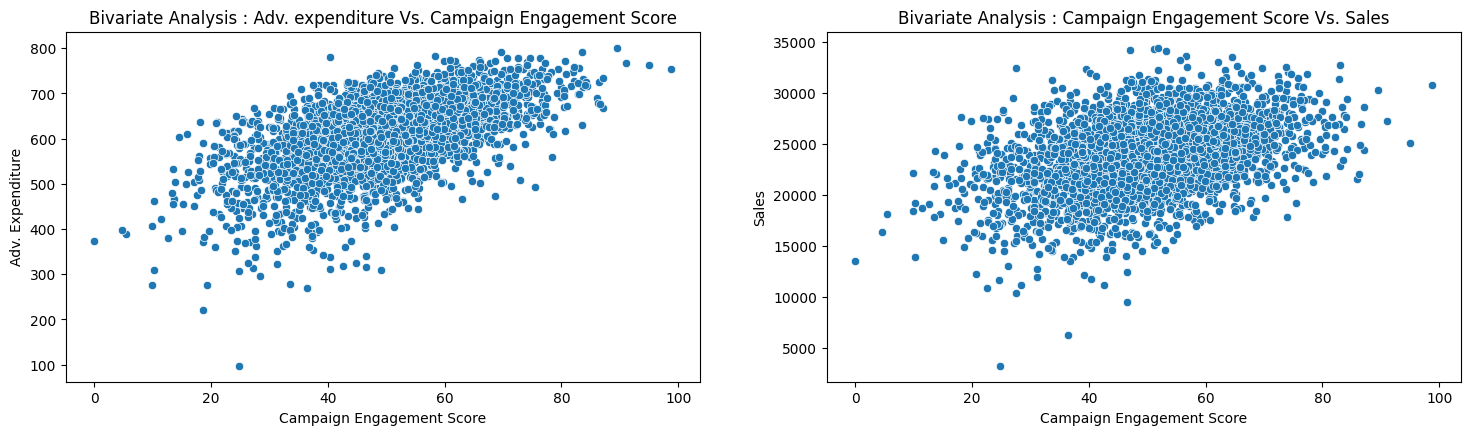

In [38]:
  plt.figure(figsize = (18,10))

plt.subplot(2, 2, 1)
plt.title("Bivariate Analysis : Adv. expenditure Vs. Campaign Engagement Score")
sns.scatterplot(data=df, x = 'Campaign Engagement Score', y = 'Advertising Expenditure')
plt.xlabel('Campaign Engagement Score')
plt.ylabel('Adv. Expenditure')
# plt.show()


plt.subplot(2, 2, 2)
plt.title("Bivariate Analysis : Campaign Engagement Score Vs. Sales")
sns.scatterplot(data=df, x = 'Campaign Engagement Score', y = 'Sales')
plt.xlabel('Campaign Engagement Score')
plt.ylabel('Sales')
plt.show()

## **Observation's :**

- Here, Advertising expenditure & campaign engagment score is postive correlated with each other, more advertising influences more customer engagement & more engagement thend to increase sales ( As we can see in 2nd plot )

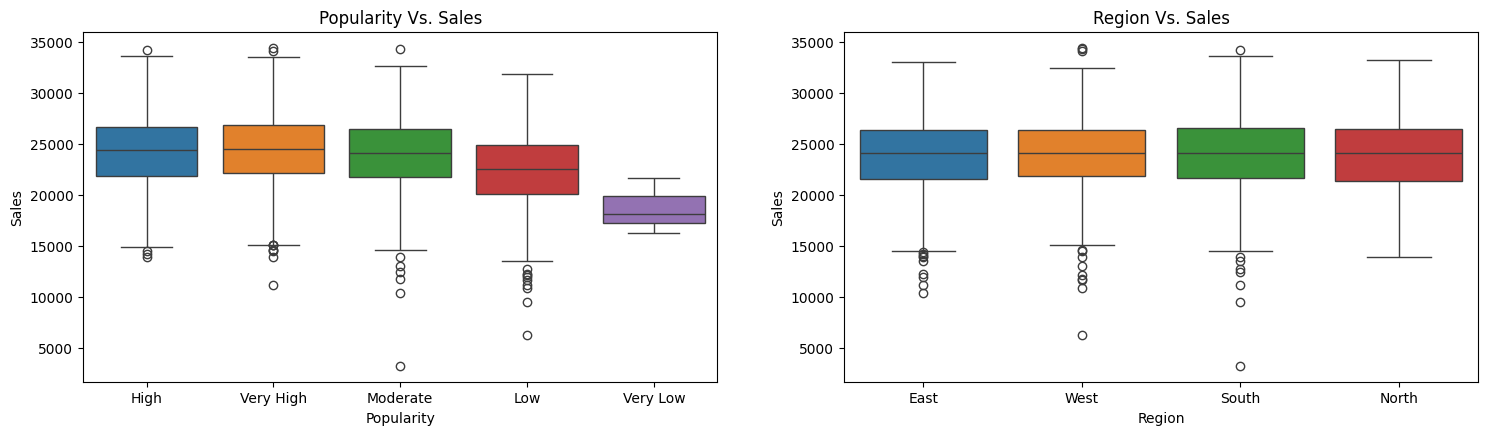

In [47]:
plt.figure(figsize = (18, 10))

plt.subplot(2, 2, 1)
plt.title("Popularity Vs. Sales")
sns.boxplot(data=df, x = 'Popularity', y = 'Sales', hue = 'Popularity')

plt.subplot(2, 2, 2)
plt.title("Region Vs. Sales")
sns.boxplot(data=df, x = 'Region', y = 'Sales', hue = 'Region')

plt.show()

## **Observation's :**

- High, Very High, Moderate popularity has same sales trend except low, very low popularity cohorts.

- as per the trend popularity has not that much influencing sales might be.

- same in Region also, region has dosent matter to sales, not thatr much. Sales seems uniform in across regions.

- Outliers are present.

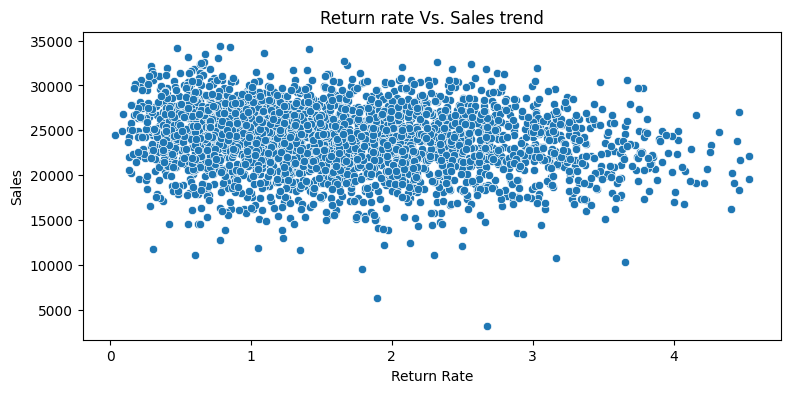

In [137]:
plt.figure(figsize = (9, 4))
plt.title("Return rate Vs. Sales trend")
sns.scatterplot(data=df ,  x = 'Return Rate', y = 'Sales')
plt.show()

## **Observation's :**

- Return rate dosen't affected on Sales. not that much

# **Data Prepration for Modelling**

In [65]:
# defining the independent & dependent variables

# here droping the sales column because sales column is target varibale now for predicting. Except 'Sales' column all columns goes into the X variable for training
X = df.drop('Sales', axis = 1)

# here y is our target variable.
Y = df['Sales']

In [66]:
# Spliting the data into two part 80-20 Ratio. one part for training & 2nd part for testing 80-20%
# 80% data goes for Training & 20% data goes for testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,    #-> Specifying the independent variable
    Y,    #-> Specifying the dependent variable
    test_size= 0.20,   # -> Specifying the test data size
    random_state= 42   # -> Specifying a seed value to enable reproducible results.
)

# **Model building**

# **Simple Linear Regression**

### **Sales Vs. Advertising Expenditure**

In [92]:
# defining the independent variable

independent_variable_1 = ['Advertising Expenditure']

In [112]:
# calling and creating instance of the Linear Regression Model

linear_regression_1 = LinearRegression()

In [113]:
# Fitting the model to training data
linear_regression_1.fit(X_train[independent_variable_1], y_train)

LinearRegression()

**Printing the slop & intercept**

Simple Linear regression Formula : **Y = mx + b**

In [114]:
print(f"Slop (m) : {linear_regression_1.coef_} \nintercept (b) : {linear_regression_1.intercept_}")

Slop (m) : [28.66748755] 
intercept (b) : 6435.891302271037


In [115]:
print(f"Sales (y) = {linear_regression_1.coef_} * {independent_variable_1} + {linear_regression_1.intercept_}")

Sales (y) = [28.66748755] * ['Advertising Expenditure'] + 6435.891302271037


**Plottin the best fit line**

In [116]:
value_fit_1 = linear_regression_1.predict(X_train[independent_variable_1])

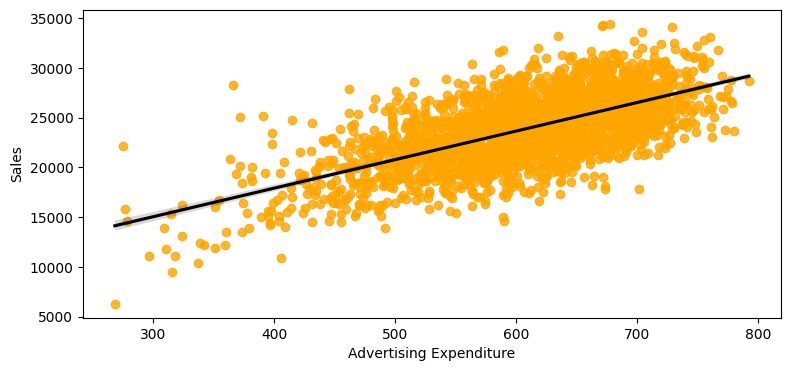

In [141]:
plt.figure(figsize = (9, 4))
sns.regplot( x = X_train[independent_variable_1], y = y_train, scatter_kws = {'color': 'Orange'}, line_kws = {'color':'Black'})
plt.show()

**Observation's :**

- Here we can see positive correlation between the Sales & Advertising expenditure.

- As Advertising Expenditure increases, sale tends to increase.

- Some outliers exist, which may impact our model performance.

### **Sales Vs. Campaign Engagement Score**

In [105]:
independent_variable_2 = ['Campaign Engagement Score']

In [117]:
linear_regression_2 = LinearRegression()

In [118]:
linear_regression_2.fit(X_train[independent_variable_2], y_train)

LinearRegression()

In [119]:
print(f"slop (m) : {linear_regression_2.coef_.round(2)} \nintercept (b) : {linear_regression_2.intercept_.round(2)}")

slop (m) : [108.57] 
intercept (b) : 18483.48


In [120]:
print(f" Sales (Y) = {linear_regression_2.coef_.round(2)} * {independent_variable_2} + {linear_regression_2.intercept_.round(2)}")

 Sales (Y) = [108.57] * ['Campaign Engagement Score'] + 18483.48


In [122]:
value_fit_2 = linear_regression_2.predict(X_train[independent_variable_2])
value_fit_2

array([22666.17006198, 22923.59314757, 24109.27896615, ...,
       23410.10807013, 26765.94419165, 24898.93486171])

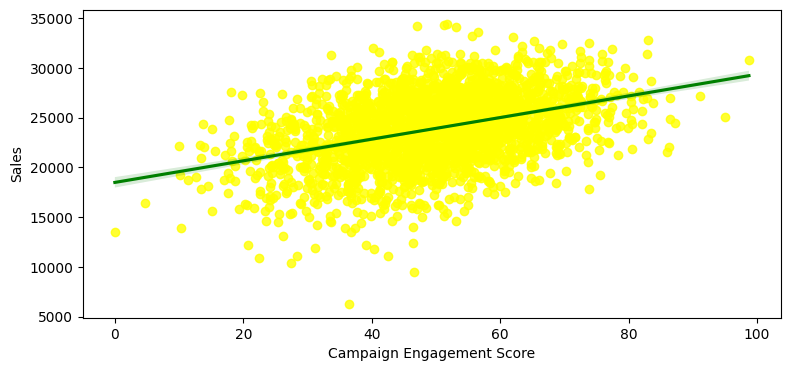

In [142]:
plt.figure(figsize= (9, 4))
sns.regplot(x= X_train[independent_variable_2], y = y_train, scatter_kws= {'color': 'Yellow'}, line_kws={'color': 'green'})
plt.show()

## **Observation's :**

- Campaign Engagement Score is positive correlation with sales. but data more spreded & some outliers are preset which may impact our model performance.

- Some time engagement score is low but sales indicates higher sales.

## **Sales Vs. Discount Percentage**

In [125]:
# defining the independent variable
independent_variable_3 = ['Discount Percentage']

In [127]:
# model defining

linear_regression_3 =  LinearRegression()

In [130]:
linear_regression_3.fit(X_train[independent_variable_3], y_train)

LinearRegression()

In [131]:
# Checking the slop & intercept
print(f"slop (y) : {linear_regression_3.coef_.round(2)} \nintercept (b) : {linear_regression_3.intercept_.round(2)}")

slop (y) : [188.39] 
intercept (b) : 18411.68


In [132]:
# simple linear regression enquations
print(f"Sales (y) = {linear_regression_3.coef_.round(2)} * {independent_variable_3} + {linear_regression_3.intercept_.round(2)}")

Sales (y) = [188.39] * ['Discount Percentage'] + 18411.68


In [135]:
value_fit_3 = linear_regression_3.predict(X_train[independent_variable_3])
value_fit_3

array([23459.41765278, 24583.39252713, 22189.11827321, ...,
       23347.09528409, 25721.08675474, 23052.08088577])

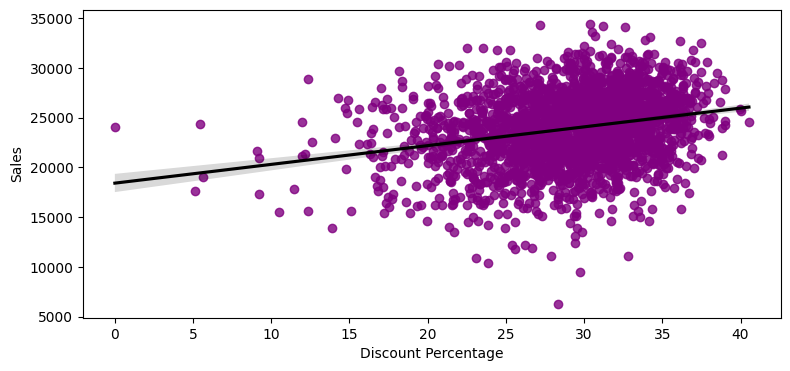

In [143]:
# plotting the graph
plt.figure(figsize = (9, 4))
sns.regplot(x = X_train[independent_variable_3], y = y_train, scatter_kws = {'color': 'purple'}, line_kws = {'color':'black'})
plt.show()

## **Observation's :**

- Discount percentage & sales have positive correlation. More discount tends to sales increase.

- Some outliers are preset which may cause our model performances.

In [89]:
df.head()

,Advertising Expenditure,Campaign Engagement Score,Discount Percentage,Average Customer Rating,Product Price,Return Rate,Length of Product Description,Region,Popularity,Sales
0,644.05,54.57,25.27,4.60,1599.58,2.13,231.19,East,High,26246.91
1,521.48,46.88,35.08,4.36,1586.46,1.55,262.69,West,Very High,21432.17
2,540.08,42.29,12.62,4.57,1301.64,2.27,324.35,South,Very High,22551.92
3,627.94,61.83,31.59,4.23,1601.04,1.04,447.71,South,Very High,27792.29
4,471.15,31.06,9.20,4.82,1496.73,3.28,310.06,East,Moderate,17354.77
